In [ ]:
import torch
import tiktoken
from configs.model import ModelConfig
from configs.training import TrainingConfig
from configs.scheduler import SchedulerConfig
from configs.optimizer import OptimizerConfig
from configs.checkpoint import CheckpointConfig
from models.deepseek import DeepSeek
from generation.sample_text import generate, generate_sample_text, text_to_token_ids,token_ids_to_text
from datasets.download_data.the_verdict.verdict import download_the_verdict
from datasets.preprocess import prepare_dataset
from datasets.dataloader import createDataLoader
from evaluation.losses import cross_entropy_loss,token_accuracy
from trainer.trainer import Trainer

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
DeepSeek_SMALL = ModelConfig(
    emb_dim=96,
    expert_dim=24,
    n_layers=12,
    n_heads=4,
    activation="gelu",
    context_length=24,
    latent_dim=48
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = DeepSeek(DeepSeek_SMALL).to(device)

In [ ]:
text = "Every effort moves you "
tokenized_text = text_to_token_ids(text, tokenizer)
ids = generate(model, tokenized_text, max_new_tokens=20, context_size=DeepSeek_SMALL.context_length)
response = token_ids_to_text(ids, tokenizer)
print(response)

Every effort moves you  Fargo


In [ ]:
res_text = generate_sample_text(model,device='cpu',tokenizer=tokenizer,text=text,max_new_tokens=20)
print(res_text)

Every effort moves you vemittedlyGirl Disappuckle newlybeamneath 1901 interviewing genomic liaison Spain Shiva nominees Libre toilets round� fired


In [ ]:
TRAIN_CONFIG = TrainingConfig(
    epoch=5,
    batch_size=2,
    stride=24,
    context_length=24
)

OPTIMIZER_CONFIG = OptimizerConfig()
SCHEDULER_CONFIG = SchedulerConfig()
CHECKPOINT_CONFIG = CheckpointConfig()

In [ ]:
raw_text,verdict_dir = download_the_verdict()
train_ids, val_ids = prepare_dataset(raw_text, tokenizer,TRAIN_CONFIG,verdict_dir)
train_dataloader = createDataLoader(train_ids, TRAIN_CONFIG)
val_dataloader = createDataLoader(val_ids, TRAIN_CONFIG)

TrainingConfig(epoch=5, batch_size=2, stride=24, context_length=24, learning_rate=0.0003, weight_decay=0.1, grad_clip=1.0, mixed_precision=False, shuffle=False, num_workers=0, drop_last=True, gradient_accumulation_steps=1, train_data_ratio=0.9)
TrainingConfig(epoch=5, batch_size=2, stride=24, context_length=24, learning_rate=0.0003, weight_decay=0.1, grad_clip=1.0, mixed_precision=False, shuffle=False, num_workers=0, drop_last=True, gradient_accumulation_steps=1, train_data_ratio=0.9)


In [9]:
trainer=Trainer(model,tokenizer,train_dataloader,val_dataloader,device,cross_entropy_loss,token_accuracy,CHECKPOINT_CONFIG,TRAIN_CONFIG,OPTIMIZER_CONFIG,SCHEDULER_CONFIG)

In [10]:
trainer.fit()           ### use arg resume_latest=True or resume_best=True to resume training

100%|██████████| 96/96 [00:57<00:00,  1.66it/s]


Checkpoint saved -> checkpoints\checkpoint_96.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves youaw
after 1 epoch global step 96 the train loss 10.431321461995443 val loss 9.449280738830566 and train acc| 0.024305555833658826 val acc| 0.028409093618392944 


100%|██████████| 96/96 [00:44<00:00,  2.15it/s]


Checkpoint saved -> checkpoints\checkpoint_192.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you the
after 2 epoch global step 192 the train loss 7.529126922289531 val loss 7.041148662567139 and train acc| 0.07052951368192832 val acc| 0.060606058686971664 


100%|██████████| 96/96 [00:43<00:00,  2.20it/s]


Checkpoint saved -> checkpoints\checkpoint_288.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves youitionally
after 3 epoch global step 288 the train loss 6.191315705577533 val loss 6.73141622543335 and train acc| 0.07812500025223319 val acc| 0.06818182021379471 


100%|██████████| 96/96 [00:45<00:00,  2.13it/s]


Checkpoint saved -> checkpoints\checkpoint_384.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you deep
after 4 epoch global step 384 the train loss 5.915961220860481 val loss 6.5944743156433105 and train acc| 0.08832465294593324 val acc| 0.06060606241226196 


100%|██████████| 96/96 [01:02<00:00,  1.54it/s]


Checkpoint saved -> checkpoints\checkpoint_480.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves youCome
after 5 epoch global step 480 the train loss 5.675473794341087 val loss 6.444090366363525 and train acc| 0.11393229197710752 val acc| 0.07765152305364609 


### loss accuracy graph

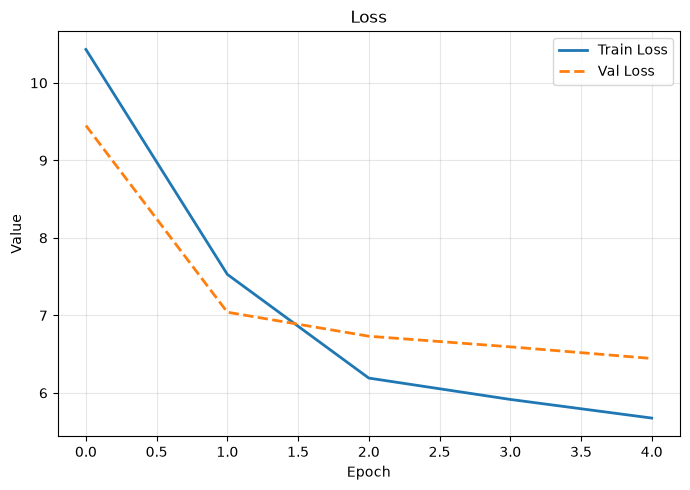

In [ ]:
trainer.metrics.plot("train_loss","val_loss")

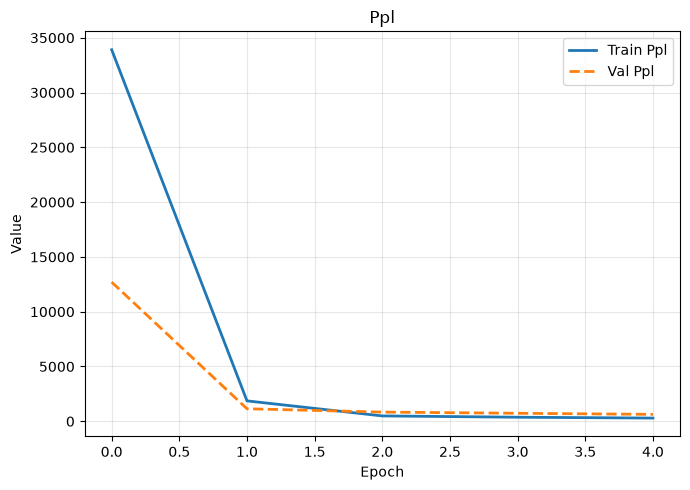

In [ ]:
trainer.metrics.plot("train_ppl","val_ppl")

In [11]:
trainer.metrics.metrics

defaultdict(list,
            {'train_loss': [10.431321461995443,
              7.529126922289531,
              6.191315705577533,
              5.915961220860481,
              5.675473794341087],
             'train_acc': [0.024305555833658826,
              0.07052951368192832,
              0.07812500025223319,
              0.08832465294593324,
              0.11393229197710752],
             'train_ppl': [33905.1250038121,
              1861.479577552265,
              488.4883904932144,
              370.9106584708969,
              291.62647679259146],
             'val_loss': [9.449280738830566,
              7.041148662567139,
              6.73141622543335,
              6.5944743156433105,
              6.444090366363525],
             'val_acc': [0.028409093618392944,
              0.060606058686971664,
              0.06818182021379471,
              0.06060606241226196,
              0.07765152305364609],
             'val_ppl': [12699.028060268829,
              1142.6